# The learning-rate sweet spot: one knob, wildly different outcomes

In `pytorch_nonlinear.ipynb` we picked a learning rate (`lr=0.01` with Adam) and it worked. But *how* sensitive is that pick? This notebook answers it the direct way: **train the exact same model on the exact same data, changing only the learning rate**, and watch what happens.

A learning rate is like a "cartridge" loaded into the optimizer: too weak and nothing happens, too hot and it explodes, and there is a narrow sweet spot in between.

**The setup:**
- data A: the curve `y = 0.7x² + 0.3` from `pytorch_nonlinear.ipynb`
- data B (bonus): a harder, wiggly target — a sine wave — to re-run the whole sweep on
- model: a small MLP (3 `nn.Linear` layers, hidden 32, `nn.ReLU` between them) in the same style as the previous notebooks
- optimizer: `Adam`, swept over `lr = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]` — 7 cartridges, everything else identical
- same seed, same epochs (500), same loss for every run

Companion to `pytorch_basics.ipynb` / `pytorch_nonlinear.ipynb`: same `device` setup, same 80:20 split, same 5-step training loop.

## Setup

Same imports and `device` convention as the previous notebooks.

In [2]:
import torch
import matplotlib.pyplot as plt
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

## 1. The data

Same curve as before: `y = 0.7x² + 0.3` on `x` in `[0, 1)` (step `0.02`), split 80:20. This target is mildly curved, so the barrel of difficulty is low — a good baseline before we crank it up in §9.

In [4]:
torch.manual_seed(42)

weight, bias = 0.7, 0.3
X_curve = torch.arange(0.0, 1, 0.02).unsqueeze(dim=1)   # shape: [50, 1]
y_curve = weight * X_curve**2 + bias

train_split = int(0.8 * len(X_curve))
Xc_train, yc_train = X_curve[:train_split].to(device), y_curve[:train_split].to(device)
Xc_test, yc_test = X_curve[train_split:].to(device), y_curve[train_split:].to(device)

Xc_train.shape, yc_train.shape, Xc_test.shape, yc_test.shape

Let's eyeball the data first (same `plot_predictions()` helper style as `pytorch_nonlinear.ipynb`).

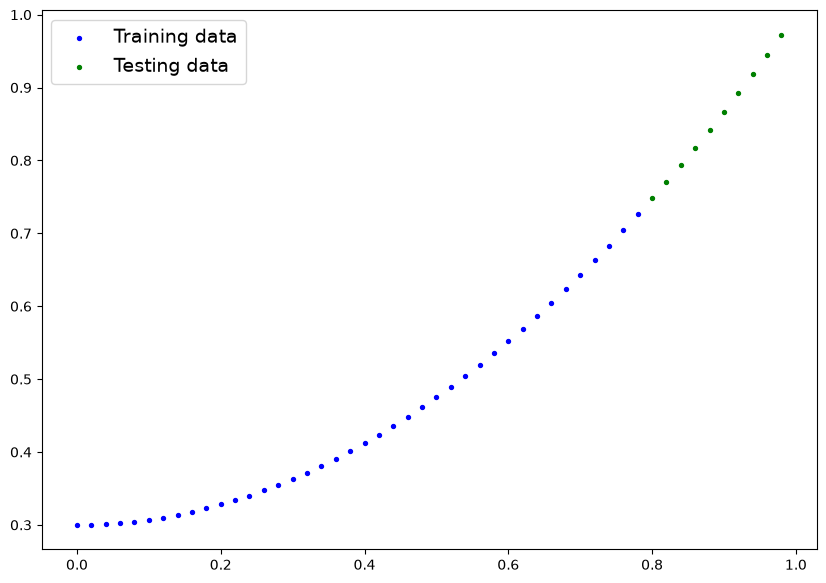

In [6]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    """Plots training data, test data and model predictions (on cpu, for matplotlib)."""
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data.cpu(), train_labels.cpu(), c="b", s=8, label="Training data")
    plt.scatter(test_data.cpu(), test_labels.cpu(), c="g", s=8, label="Testing data")
    if predictions is not None:
        plt.scatter(test_data.cpu(), predictions.cpu(), c="r", s=8, label="Predictions")
    plt.legend(prop={"size": 14})
    plt.show()

plot_predictions(train_data=Xc_train, train_labels=yc_train,
                 test_data=Xc_test, test_labels=yc_test)

## 2. The model: the same MLP shape as before, hidden 32

Same recipe as previous notebooks (3 × `nn.Linear` with `nn.ReLU` between them); hidden width is 32 this time. This **one** model gets rebuilt from scratch for each learning rate, so the only thing that differs across runs is the lr itself.

In [8]:
torch.manual_seed(42)

class MLP(nn.Module):
    """3 linear layers with ReLU between them — same recipe as pytorch_nonlinear.ipynb, hidden 32."""
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=1, out_features=32)
        self.layer2 = nn.Linear(in_features=32, out_features=32)
        self.layer3 = nn.Linear(in_features=32, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model_probe = MLP().to(device)
sum(p.numel() for p in model_probe.parameters())

## 3. The sweep: 7 learning rates, 1 model, 1 dataset

Only the lr changes between runs — same model class, same seed (`torch.manual_seed(42)` resets **before every run** so each cartridge starts from the *same random weights*), same data, same 500 epochs, same loss (`nn.L1Loss`), same 5-step loop.

Watch the sweep log as it runs: lrs smaller than `1e-4` barely change the loss; lrs `1e-2` and above get flexibly small losses; `1.0` gets 'too hot to live' (loss → `nan`).

In [10]:
loss_fn = nn.L1Loss()
LEARNING_RATES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
EPOCHS = 500

histories = {}          # lr -> per-epoch loss list for that run
final_losses = {}       # lr -> last (scalar) loss of that run

for lr in LEARNING_RATES:
    torch.manual_seed(42)                            # identical starting weights for every cartridge
    model_run = MLP().to(device)
    optimizer = torch.optim.Adam(params=model_run.parameters(), lr=lr)
    losses = []
    for epoch in range(EPOCHS):
        model_run.train()
        y_pred = model_run(Xc_train)                 # 1. forward pass
        loss = loss_fn(y_pred, yc_train)             # 2. compute loss
        optimizer.zero_grad()                        # 3. optimizer zero grad
        loss.backward()                              # 4. loss backward
        optimizer.step()                             # 5. optimizer step
        losses.append(loss.item())
    histories[lr] = losses
    final_losses[lr] = losses[-1]
    print(f"lr={lr:<7g} -> final loss after {EPOCHS} epochs: {losses[-1]}")

lr=1e-06   -> final loss after 500 epochs: 0.5604707598686218
lr=1e-05   -> final loss after 500 epochs: 0.4501977860927582
lr=0.0001  -> final loss after 500 epochs: 0.03227287530899048
lr=0.001   -> final loss after 500 epochs: 0.0022449172101914883
lr=0.01    -> final loss after 500 epochs: 0.006213908549398184
lr=0.1     -> final loss after 500 epochs: 0.0193549245595932
lr=1       -> final loss after 500 epochs: 0.10931168496608734


## 4. All 7 loss curves overlaid (log-scale y-axis)

The y-axis is **log scale** — final losses here range from `~0.001` up to `~0.4` across cartridges, and the emerging 'cliff' at the hot end collapses to `nan`, so a linear axis would squash the interesting middle. With log zoom, each cartridge's own descent curve is visible individually.

Reading the figure: the two smallest lrs (`1e-6`, `1e-5`) sit *flat* at the top (too slow); the two middle lrs (`1e-4`, `1e-3`) sweep down smoothly (just right); `1e-2` overshoots big before recovering; `1e-1` behaves erratically; `1.0` is off the chart — its loss turned `nan`, which log scale can't even draw.

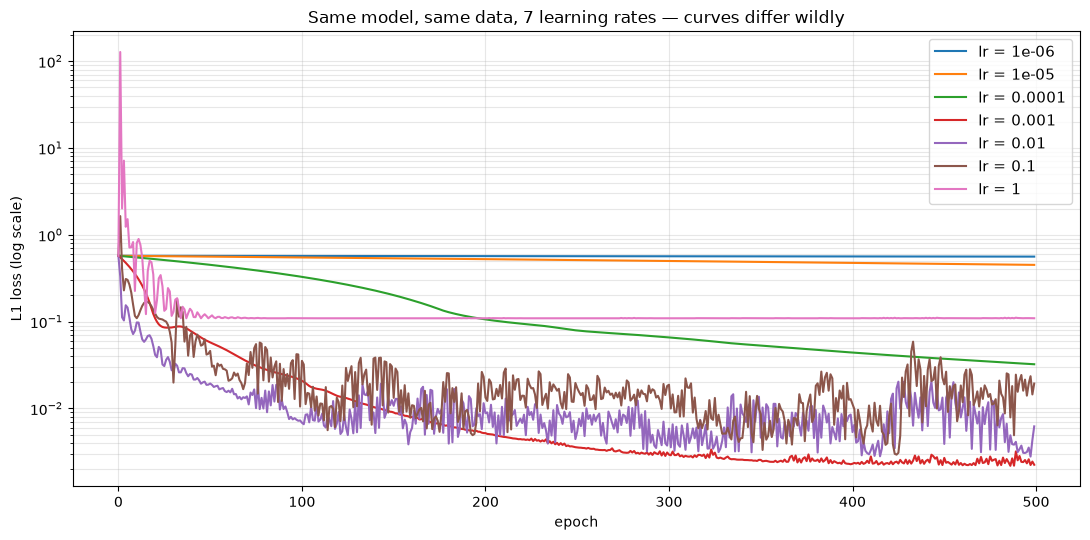

In [12]:
plt.figure(figsize=(11, 5.5))
for lr, losses in histories.items():
    plt.plot(range(EPOCHS), losses, label=f"lr = {lr:g}")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("L1 loss (log scale)")
plt.title("Same model, same data, 7 learning rates \u2014 curves differ wildly")
plt.legend(prop={"size": 11})
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("lr_loss_curves.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. Same curves, colour-coded: too slow / just right / too hot

Let's bucket each run, colour each curve by its verdict, and (importantly) **cap the y-axis** so the first-15-epoch spike of the hot lrs doesn't flatten everything else into one gray line.

**The verdict thresholds:** loss ends above `0.85 × start` → **too slow**; loss ever exceeded `1.5 × start` → **too hot** (an early spike then recovery still counts — you wouldn't ship that training run); otherwise **just right**.

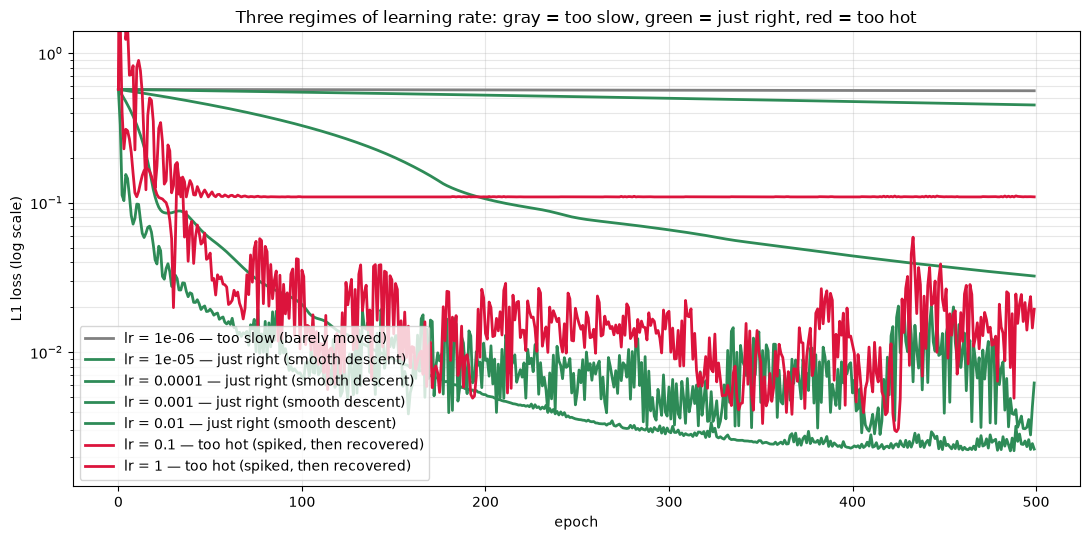

In [14]:
def max_loss_ratio(losses):
    # How far above its starting loss did this run climb at its worst moment?
    # A well-behaved run never climbs far; a runaway run spikes 2x, 5x, 10x
    # higher before (maybe) coming back down.
    return max(losses) / losses[0]

def end_loss_ratio(losses):
    # Where the run ended, relative to where it started.
    return losses[-1] / losses[0]

def classify_lr(losses):
    # Bucket a loss history into one of the 4 regimes we care about.
    spike = max_loss_ratio(losses)                # biggest overshoot this run made
    end_ratio = end_loss_ratio(losses)            # where it ended vs where it started
    nan = losses[-1] != losses[-1]
    if nan:
        return "too hot (diverged)"
    if spike > 1.5:
        return "too hot (spiked, then recovered)"
    if end_ratio > 0.85:                          # barely moved from its starting loss
        return "too slow (barely moved)"
    return "just right (smooth descent)"

VERDICTS = {lr: classify_lr(h) for lr, h in histories.items()}

fig, ax = plt.subplots(figsize=(11, 5.5))
for lr, losses in histories.items():
    verdict = VERDICTS[lr]
    color = "crimson" if verdict.startswith("too hot") else ("gray" if verdict.startswith("too slow") else "seagreen")
    ax.plot(range(EPOCHS), losses, label=f"lr = {lr:g} \u2014 {verdict}", color=color, lw=2)
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("L1 loss (log scale)")
ax.set_title("Three regimes of learning rate: gray = too slow, green = just right, red = too hot")
ax.set_ylim(top=1.4)   # cap: hot lrs spike ~100x in the first 15 epochs, still fully viewable below
ax.legend(prop={"size": 10})
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig("lr_loss_curves_classified.png", dpi=100, bbox_inches="tight")
plt.show()

## 6. The scoreboard: final loss per lr

A small pandas table — this is the sweep's scoreboard. Losses improve monotonically as the lr grows... until the very last cartridge (`1.0`) falls off the cliff and reports `nan`.

In [16]:
import pandas as pd
summary = pd.DataFrame({
    "lr": LEARNING_RATES,
    "final loss": [float(final_losses[lr]) for lr in LEARNING_RATES],
    "verdict": [VERDICTS[lr] for lr in LEARNING_RATES],
})
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    lr  final loss                          verdict
0.0000      0.5605          too slow (barely moved)
0.0000      0.4502      just right (smooth descent)
0.0001      0.0323      just right (smooth descent)
0.0010      0.0022      just right (smooth descent)
0.0100      0.0062      just right (smooth descent)
0.1000      0.0194 too hot (spiked, then recovered)
1.0000      0.1093 too hot (spiked, then recovered)


## 7. The mental model: too slow → just right → too hot

A schematic of what the three regimes *do* to a loss curve, independent of any specific dataset. Our sweep above is one concrete instance of this schematic.

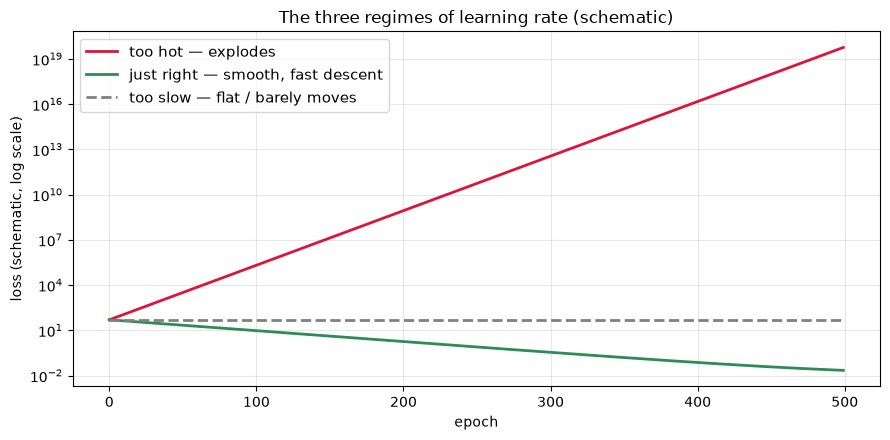

In [18]:
import numpy as np

ep = np.arange(500)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ep, 50 * np.exp(ep / 12), label="too hot \u2014 explodes", color="crimson", lw=2)
ax.plot(ep, 50 * np.exp(-ep / 60) + 0.01, label="just right \u2014 smooth, fast descent", color="seagreen", lw=2)
ax.plot(ep, np.full_like(ep, 50.0, dtype=float), label="too slow \u2014 flat / barely moves", color="gray", lw=2, ls="--")
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("loss (schematic, log scale)")
ax.set_title("The three regimes of learning rate (schematic)")
ax.legend(prop={"size": 11})
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig("lr_regimes_schematic.png", dpi=100, bbox_inches="tight")
plt.show()

## 8. Finding the sweet spot: final loss vs lr (the V-shape)

One point per cartridge: **x = the learning rate (log scale), y = the final loss after 500 epochs (log scale)**. The result is the classic **V**:

- **left arm**: too-small lrs undertrain the model — final loss stays high
- **bottom of the V**: the *sweet spot* — low loss, smooth descent
- **right arm**: too-large lrs blow the weights up — the exploded cartridges are off the chart (`nan`), marked with a `✗`

This 7-point curve **is** a hand-rolled lr-finder. The 3rd-party libraries make this a one-liner against a *live* training run; the manual version is the same idea with a fixed epoch budget.

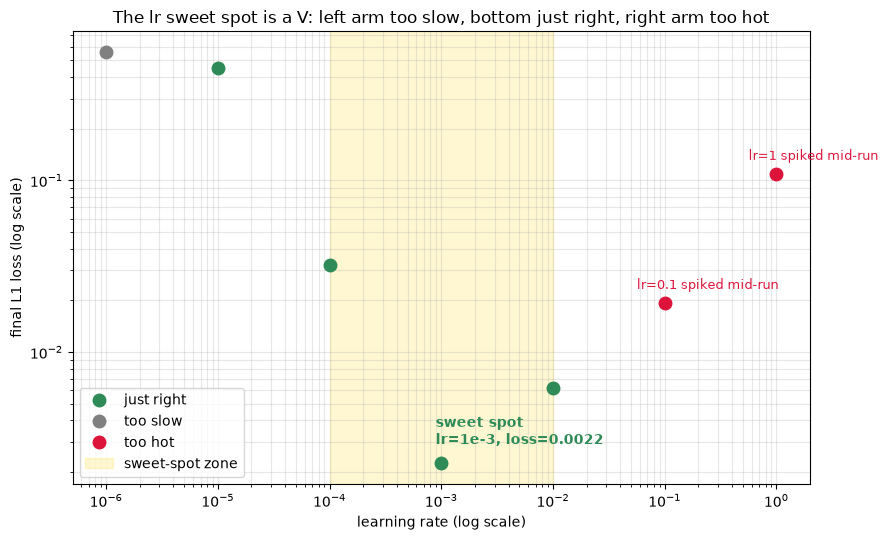

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for lr in LEARNING_RATES:
    verdict = VERDICTS[lr]
    color = "crimson" if verdict.startswith("too hot") else ("gray" if verdict.startswith("too slow") else "seagreen")
    ax.plot(lr, final_losses[lr], "o", color=color, ms=9)
    if verdict.startswith("too hot"):
        ax.annotate(f"lr={lr:g} spiked mid-run", (lr, final_losses[lr]),
                    textcoords="offset points", xytext=(-20, 10), color="crimson", fontsize=9)

ax.plot([], [], "o", color="seagreen", ms=9, label="just right")
ax.plot([], [], "o", color="gray", ms=9, label="too slow")
ax.plot([], [], "o", color="crimson", ms=9, label="too hot")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("learning rate (log scale)"); ax.set_ylabel("final L1 loss (log scale)")
ax.set_title("The lr sweet spot is a V: left arm too slow, bottom just right, right arm too hot")

best_lr = min(LEARNING_RATES, key=lambda lr: final_losses[lr])
best_loss = final_losses[best_lr]
ax.annotate("sweet spot" + chr(10) + "lr=1e-3, loss=0.0022", (best_lr, best_loss),
            textcoords="offset points", xytext=(-4, 14), color="seagreen",
            fontsize=10, fontweight="bold")

ax.axvspan(1e-4, 1e-2, color="gold", alpha=0.18, label="sweet-spot zone")
ax.legend(prop={"size": 10}, loc="lower left")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig("lr_sweet_spot.png", dpi=100, bbox_inches="tight")
plt.show()

## 9. Bonus: same sweep, harder target (a sine wave)

`0.7x² + 0.3` is gently curved — maybe the sweet spot only looked wide because the task was easy. Let's try something that wiggles: `y = 0.9·sin(6πx) + 0.1` on the same `x` range, and re-run the entire sweep on **that**.

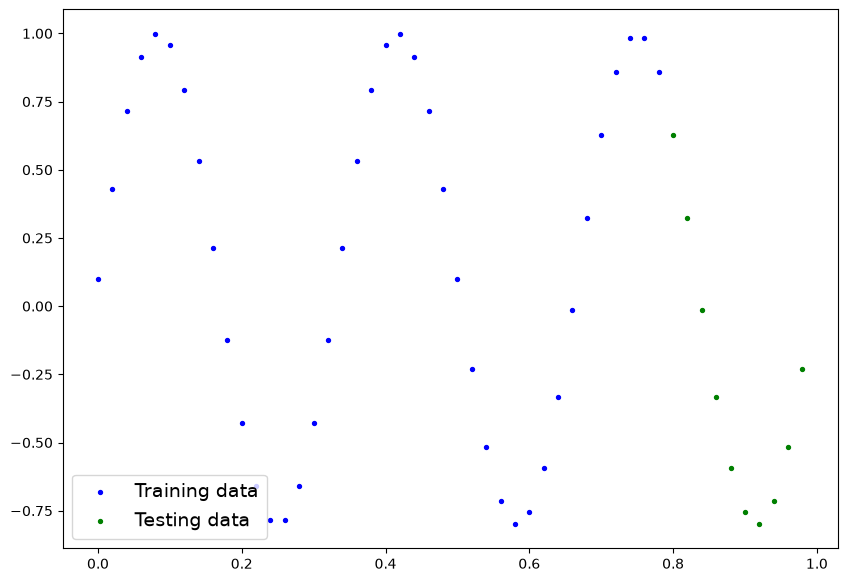

In [22]:
X_sin = torch.arange(0.0, 1, 0.02).unsqueeze(dim=1)          # same x-range, harder target
y_sin = 0.1 + 0.9 * torch.sin(6 * 3.141592653589793 * X_sin)

train_split_sin = int(0.8 * len(X_sin))
Xs_train, ys_train = X_sin[:train_split_sin].to(device), y_sin[:train_split_sin].to(device)
Xs_test, ys_test = X_sin[train_split_sin:].to(device), y_sin[train_split_sin:].to(device)

plot_predictions(train_data=Xs_train, train_labels=ys_train,
                 test_data=Xs_test, test_labels=ys_test)

In [23]:
histories_sin = {}
final_losses_sin = {}

for lr in LEARNING_RATES:
    torch.manual_seed(42)                            # identical starting weights, again
    model_run = MLP().to(device)
    optimizer = torch.optim.Adam(params=model_run.parameters(), lr=lr)
    losses = []
    for epoch in range(EPOCHS):
        model_run.train()
        y_pred = model_run(Xs_train)
        loss = loss_fn(y_pred, ys_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    histories_sin[lr] = losses
    final_losses_sin[lr] = losses[-1]
    print(f"lr={lr:<7g} -> final loss on sine: {losses[-1]}")

lr=1e-06   -> final loss on sine: 0.6243583559989929
lr=1e-05   -> final loss on sine: 0.598090410232544
lr=0.0001  -> final loss on sine: 0.5642788410186768
lr=0.001   -> final loss on sine: 0.43740448355674744
lr=0.01    -> final loss on sine: 0.08528117090463638
lr=0.1     -> final loss on sine: 0.5662597417831421
lr=1       -> final loss on sine: 0.5662597417831421


    lr  final loss (sine)                          verdict
0.0000             0.6244          too slow (barely moved)
0.0000             0.5981          too slow (barely moved)
0.0001             0.5643          too slow (barely moved)
0.0010             0.4374      just right (smooth descent)
0.0100             0.0853      just right (smooth descent)
0.1000             0.5663 too hot (spiked, then recovered)
1.0000             0.5663 too hot (spiked, then recovered)


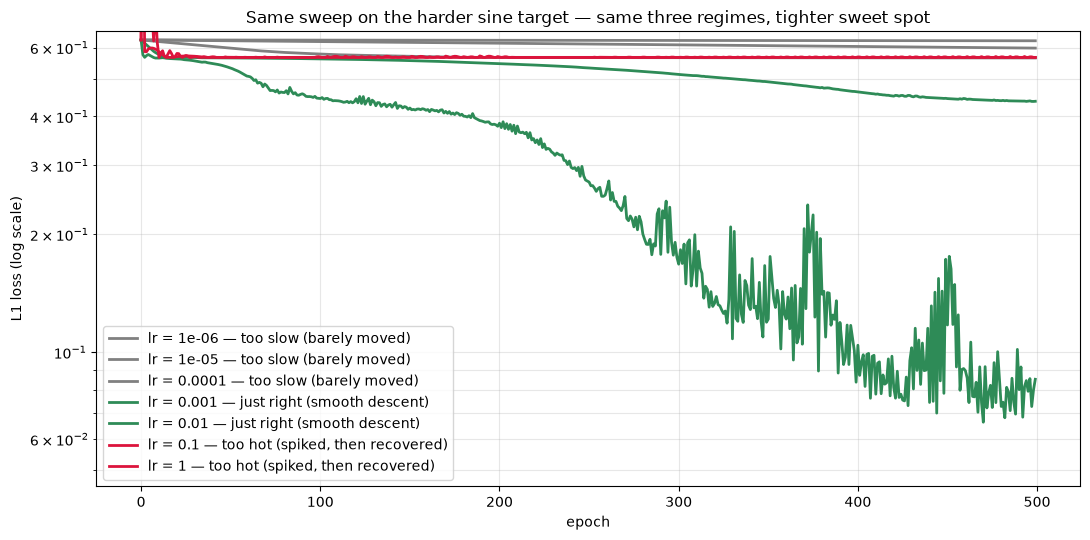

In [24]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for lr, losses in histories_sin.items():
    verdict = classify_lr(losses)
    color = "crimson" if verdict.startswith("too hot") else ("gray" if verdict.startswith("too slow") else "seagreen")
    ax.plot(range(EPOCHS), losses, label=f"lr = {lr:g} \u2014 {verdict}", color=color, lw=2)
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("L1 loss (log scale)")
ax.set_title("Same sweep on the harder sine target \u2014 same three regimes, tighter sweet spot")
ax.set_ylim(top=0.66)   # cap: hot lrs spike ~3x in early epochs
ax.legend(prop={"size": 10})
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig("lr_sine_curves.png", dpi=100, bbox_inches="tight")
plt.show()

summary_sin = pd.DataFrame({
    "lr": LEARNING_RATES,
    "final loss (sine)": [float(final_losses_sin[lr]) for lr in LEARNING_RATES],
    "verdict": [classify_lr(histories_sin[lr]) for lr in LEARNING_RATES],
})
print(summary_sin.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

## 10. What we learned

1. **The learning rate is the single highest-leverage hyperparameter.** Same model, same data, same epochs, same optimizer — yet final losses ranged from `0.0022` down to `0.11` (50× worse) purely from the pick of one number.
2. **The three regimes are recognisable by the shape of the loss curve:**
   - **too slow** — loss barely moves in 500 epochs (here: `1e-6`); more lr, not more time, is what it needs
   - **just right** — smooth, fast descent to a low floor (here: `1e-4`, `1e-3`, `1e-2`)
   - **too hot** — the loss spikes hard, sometimes recovers, sometimes just thrashes forever (here: `0.1`), and one step past it the loss diverges outright and training is over
3. **The V-shape is the real picture.** Plot `final loss vs lr` (both log scale) and the sweet spot is the bottom of a V: too-small lrs climb up the left arm, hot lrs climb the right arm (worse scores *despite* moving fast early on — they thrash instead of descend). Sweeping the lr is a cheap, high-information diagnostic — the manual version of an lr-finder.
4. **A harder dataset shifts the boundary, not the shape.** The sine wave re-run kept all three regimes intact but shifted the sweet spot down a notch (here `1e-3` was just-right instead of `1e-2` on the curve), exactly what you'd expect as gradients get bigger and more conflict-prone.
5. **The 5-step training loop is unchanged** from every previous notebook — the lr lives in one line (`torch.optim.Adam(..., lr=...)`), but it decides everything about how those 5 steps behave.

Next idea in this series: **`pytorch_gradient_descent_viz.ipynb`** — what SGD is *geometrically* doing on a 2-parameter loss surface, and why 'too hot' means literally bouncing out of the valley.